In [1]:
import cooperative_tasep_lib as tasep
import numpy as np
import matplotlib.pyplot as plt
import torch
from utils import Plot, CollectionPlots, CollectionAnalysis, Theoretical
import time
import sys
from joblib import Parallel, delayed
import logging
logging.basicConfig(filename='debug.log', level=logging.DEBUG)

In [2]:
L = 1000
T = 100

kon=0.1
koff=1
kstep=100
kq=100

q=4

In [6]:
def secure_ssim(L, T, kon, koff, kstep, kq, q):
    data, activation, nn, times, res, dts = tasep.ssim(L, T, kon, koff, kstep, kq, q)
    sys.stdout.flush()
    return data, activation

In [7]:
class MultipleExecutionDetailed:    
    @staticmethod
    def same_conf_parallel(L, T, kon, koff, kstep, kq, q, num=100):
        results = Parallel(n_jobs=10, prefer="threads")(
            delayed(secure_ssim)(L, T, kon, koff, kstep, kq, q)
            for _ in range(num)
        )
        data = [res[0] for res in results]
        activation = [res[1] for res in results]
        return (np.stack(data, axis=-1), np.stack(activation, axis=-1))

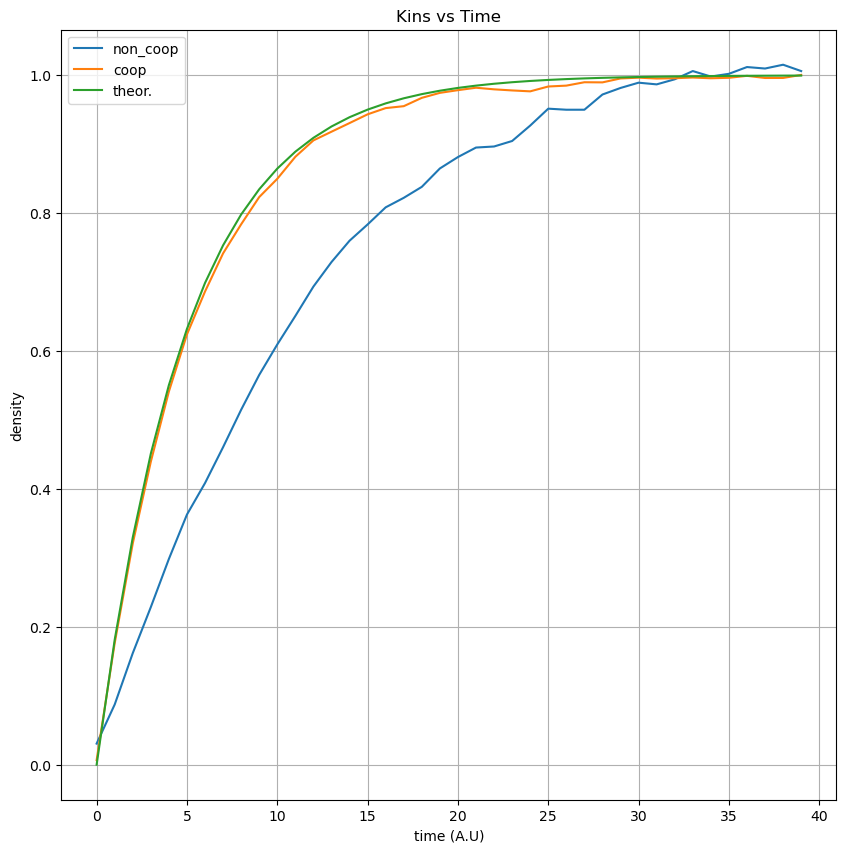

In [12]:
fig = CollectionPlots.timeseries([series_a[:40], series_b[:40], y/0.5], labels=["non_coop", "coop", "theor."]);

In [202]:
class Theoretical:
    class evolution:
        def non_coop(dt, tmax, kon, koff):
            f = kon/(kon+koff)
            x = np.arange(0, tmax, dt)
            y = f*(1-np.exp(-(kon+koff)*x))
            return x, y

        # def coop(dt, tmax, kon, koff, q, a):
        #     x = np.arange(0, tmax, dt)
        #     y = np.zeros_like(x)
        #     Q = q-1
        #     for i in range(len(x)-1):
        #         y[i+1]= dt* (
        #             kon*(Q)*a[i] - kon*y[i] - (kon*Q*a[i] - kon*y[i]+ koff)*y[i]
        #         )

        #     return x, y

        def coop(dt, tmax, kon, koff, q, a):
            x = np.arange(0, tmax, dt)
            y = np.zeros_like(x)
            Q = q-1
            for i in range(len(x)-1):
                y[i+1] = y[i] + dt * (kon*(1-y[i]) + Q*kon*a[i] - koff*y[i])

            return x, y

        def activation(dt, tmax, kon, koff, q, kstep, kq, y, nn, na):
            x = np.arange(0, tmax, dt)
            a = np.zeros_like(x)

            for i in range(len(x)-1):
                a[i+1] = max(0, (a[i] + dt * (koff*y[i] + kstep *
                             y[i]*(1-nn[i]-na[i]) - kq*a[i])))

            return x, a

        def activation_implicit_euler(dt, tmax, kon, koff, q, kstep, kq, y, nn, na):
            x = np.arange(0, tmax, dt)
            a = np.zeros_like(x)

            for i in range(len(x) - 1):
                a_next = (a[i] + dt * (koff * y[i+1] + kstep * y[i+1]
                          * (1 - nn[i+1] - na[60]))) / (1 + dt * kq)
                # a_next = (a[i] + dt * (koff * y[i+1] + kstep * y[i+1]
                #           * (1 - nn[i+1] - na[i+1]))) / (1 + dt * kq)
                a[i + 1] = max(0, a_next)

            return x, a
        






        def activation_rk4(dt, tmax, kon, koff, q, kstep, kq, y, nn, na):
            x = np.arange(0, tmax, dt)
            a = np.zeros_like(x)

            for i in range(len(x) - 1):
                t = x[i]
                a_i = a[i]
                y_i = y[i]
                nn_i = nn[i]
                na_i = na[i]

                def f(a, y, nn, na):
                    return koff * y + kstep * y * (1 - nn - na) - kq * a

                k1 = dt * f(a_i, y_i, nn_i, na_i)
                k2 = dt * f(a_i + 0.5 * k1, y_i, nn_i, na_i)
                k3 = dt * f(a_i + 0.5 * k2, y_i, nn_i, na_i)
                k4 = dt * f(a_i + k3, y_i, nn_i, na_i)

                a[i + 1] = a_i + (k1 + 2 * k2 + 2 * k3 + k4)

            return x, a

        # def activation_rk4(dt, tmax, kon, koff, q, kstep, kq, y, nn):
        #     x = np.arange(0, tmax, dt)
        #     a = np.zeros_like(x)

        #     for i in range(len(x) - 1):
        #         t = x[i]
        #         a_i = a[i]
        #         y_i = y[i]
        #         nn_i = nn[i]

        #         k1 = dt * (koff * y_i + kstep * y_i * (1 - nn_i) - kq * a_i)
        #         k2 = dt * (koff * y_i + kstep * y_i * (1 - nn_i) - kq * (a_i + 0.5 * k1))
        #         k3 = dt * (koff * y_i + kstep * y_i * (1 - nn_i) - kq * (a_i + 0.5 * k2))
        #         k4 = dt * (koff * y_i + kstep * y_i * (1 - nn_i) - kq * (a_i + k3))

        #         a[i + 1] = a_i + (k1 + 2 * k2 + 2 * k3 + k4) / 6

        #     return x, a

In [53]:
data_coop, activation_coop = MultipleExecutionDetailed.same_conf_parallel(300, 100, 0.1, 1, 100, 100, 4, num = 50)
data_non, activation_non = MultipleExecutionDetailed.same_conf_parallel(300, 100, 1, 1, 100, 100, 1, num = 50)

In [173]:
# Nseries_coop = CollectionAnalysis.normalize_at_time(data_coop, 40)
# Nseries_non = CollectionAnalysis.normalize_at_time(data_non, 40)

series_coop = CollectionAnalysis.total_density_time(data_coop)
# series_non = CollectionAnalysis.total_density_time(data_non)

activation = CollectionAnalysis.total_density_time(activation_coop)

x, y_coop = Theoretical.evolution.coop(0.1, 4, 0.1, 1, 4, activation[:40])
nn = count_ratio_of_right_neigbors_tensor(data_coop)
na = count_ratio_of_right_activions_tensor(data_coop, activation_coop)

# x, y_non = Theoretical.evolution.non_coop(0.1, 4, 1, 1)

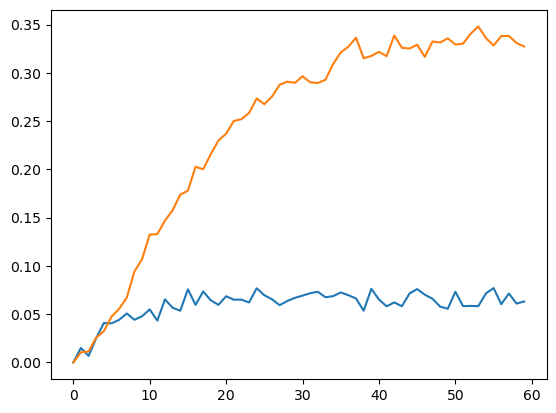

In [198]:
plt.plot(na[:60])
plt.plot(nn[:60])

In [203]:
x, activation_th = Theoretical.evolution.activation_implicit_euler(0.1, 4, 0.1, 1, 4, 100, 100, series_coop, nn, na)

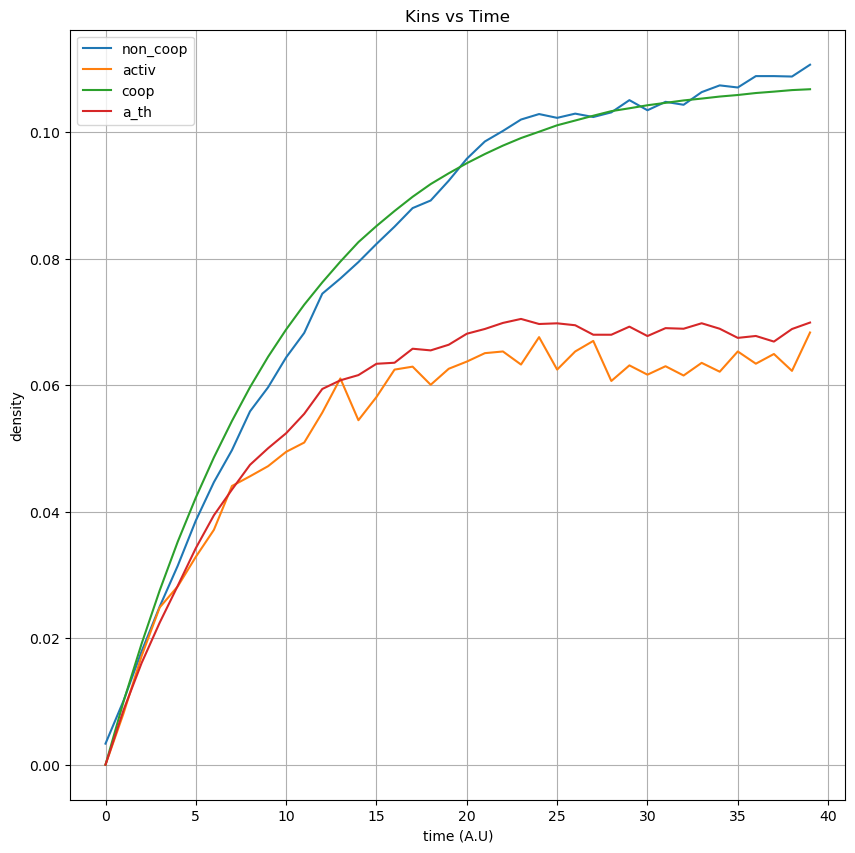

In [210]:
CollectionPlots.timeseries([series_coop[:40], activation[:40], y_coop, activation_th], labels=["non_coop", "activ","coop", "a_th"]);

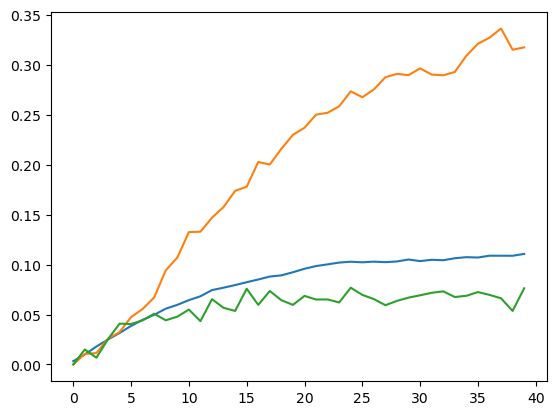

In [212]:
plt.plot(series_coop[:40])
# plt.plot(activation[:40])
plt.plot(nn[:40])
plt.plot(na[:40])

In [92]:
data_coop.shape


(1001, 300, 50)

In [95]:
test = data_coop[:, :, 1]

In [96]:
test

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1]], dtype=int32)

In [170]:
def count_ratio_of_right_neighbors(snapshot: np.array):
    S = np.sum(snapshot)
    diff = snapshot[1:]-snapshot[:-1]
    t1 = diff == 0
    t2 = snapshot[:-1]
    C = np.sum(t1 & t2)
    return C/S


def count_ratio_of_right_neighbors_matrix(data: np.array) -> np.array:
    row_ratios = np.apply_along_axis(
        count_ratio_of_right_neighbors, axis=1, arr=data)
    return row_ratios


def count_ratio_of_right_neigbors_tensor(tensor: np.array) -> np.array:
    num_sims = tensor.shape[2]
    master = np.zeros((tensor.shape[0], num_sims))
    for i in range(num_sims):
        master[:, i] = count_ratio_of_right_neighbors_matrix(tensor[:, :, i])
    return np.mean(master, axis=1)


def count_ratio_of_right_activions(encoded_data: np.array):
    # assert (np.max(encoded_data) == 2)
    # print(np.max(encoded_data))
    diff = encoded_data[1:] - encoded_data[:-1]
    t1 = diff == 1
    t2 = encoded_data[:-1] == 1
    S = np.sum(t2)
    C = np.sum(t1 & t2)
    return C/S


def count_ratio_of_right_activions_matrix(data: np.array, activated_sites: np.array) -> np.array:
    encoded_data = data + 2*activated_sites
    row_ratios = np.apply_along_axis(
        count_ratio_of_right_activions, axis=1, arr=encoded_data)
    return row_ratios


def count_ratio_of_right_activions_tensor(tensor_data: np.array, tensor_activated_sites: np.array) -> np.array:
    assert (tensor_data.shape == tensor_activated_sites.shape)
    num_sims = tensor_data.shape[2]
    master = np.zeros((tensor_data.shape[0], num_sims))
    for i in range(num_sims):
        master[:, i] = count_ratio_of_right_activions_matrix(
            tensor_data[:, :, i], tensor_activated_sites[:, :, i])
    return np.mean(master, axis=1)

array([0.        , 0.015     , 0.00681818, ..., 0.06283608, 0.05615773,
       0.06393238])